<a href="https://colab.research.google.com/github/sahdahx/PDS/blob/main/PDS_T9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tugas 9: Sampling & Statistical Inference - Pengantar Data Sains**
> Nama: Sahda Huwaidah Estiningtyas

> NIM: 24/545080/PA/23156

> email: sahdahuwaidahestiningtyas@mail.ugm.ac.id

# **Assignment - Week 9**

Gunakan salah satu:

1. data saham (Yahoo Finance)
2. data ekonomi (inflasi, GDP, dll)
3. dataset publik yang lain

Kemudian
1. Ambil data (minimal 100 observasi), tentukan mean dan std

2. Ambil beberapa sampel acak dan bangun sampling distribution, confidence interval, dan interpretasikan hasil

3. Jawab pertanyaan analitis berikut

    a. Apakah sampel cukup merepresentasikan populasi?

    b. Seberapa besar ketidakpastian estimasi?

    c. Apa implikasi untuk pengambilan keputusan?

## 1) Deskripsi Dataset

Dataset yang digunakan adalah **[Global Stock Market Trading Value](https://www.kaggle.com/datasets/omarshahrukh/stocks-traded-total-value-current-us)** yang bersumber dari World Bank (World Development Indicators).

Dataset ini mencakup periode waktu yang panjang, yaitu dari tahun 1975 hingga 2024 sehingga dapat dikategorikan sebagai data time series (deret waktu) dengan dimensi lintas negara.

Unit analisis pada dataset ini adalah **country-year**, di mana setiap baris merepresentasikan satu negara pada satu tahun tertentu dengan nilai aktivitas pasar saham yang tercatat.
Dataset ini menggambarkan total nilai transaksi pasar saham sebagai indikator aktivitas dan likuiditas pasar keuangan global.

Variabel utama dalam dataset meliputi:

* `country`: nama negara atau wilayah
* `year`: tahun observasi (1975–2024)
* `stock_trading_value`: total nilai transaksi pasar saham dalam USD

In [ ]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
np.random.seed(123)

# Membaca data
df = pd.read_csv("stocks_traded_total_value.csv")
df

,Country Name,Year,Value (USD),Status
0,Arab World,2006,1.585737e+12,Normal value
1,Arab World,2010,3.069249e+11,Normal value
2,Arab World,2011,3.792060e+11,Normal value
3,Arab World,2012,5.984638e+11,Normal value
4,Arab World,2014,8.071476e+11,Normal value
...,...,...,...,...
4075,Zimbabwe,1995,1.394400e+08,Normal value
4076,Zimbabwe,1996,2.341300e+08,Normal value
4077,Zimbabwe,1997,3.128500e+08,Normal value
4078,Zimbabwe,1998,8.026000e+07,Normal value


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4080 entries, 0 to 4079
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  4080 non-null   object 
 1   Year          4080 non-null   int64  
 2   Value (USD)   4080 non-null   float64
 3   Status        4080 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 127.6+ KB


In [ ]:
# Mean dan Std (Populasi / Dataset)
data = df['Value (USD)'].dropna()
pop_mean = data.mean()
pop_std = data.std(ddof=1)

print("Mean populasi :", pop_mean)
print("Std populasi  :", pop_std)

Mean populasi : 3391412463743.6934
Std populasi  : 11428552064172.49


**Interpretasi:**

Mean populasi sebesar **3.39 × 10¹² USD** menunjukkan bahwa rata-rata nilai transaksi pasar saham global berada pada level triliunan dolar. Hal ini dapat diartikan terjadi aktivitas pasar yang sangat besar dan heterogen antar negara.

Standar deviasi sebesar **1.14 × 10¹³ USD** jauh lebih besar dibanding mean, yang menunjukkan adanya variasi ekstrem antar negara dan tahun. Hal ini juga berarti distribusi data sangat menyebar (high dispersion) dan kemungkinan bersifat right-skewed dengan beberapa negara memiliki nilai transaksi yang sangat tinggi dibanding mayoritas negara lain.


## 2) Sampling Distribution & Confidence Interval

Mean sampling distribution : 3433389038745.755
CI 95% : (np.float64(799640323010.9916), np.float64(7150673093454.756))


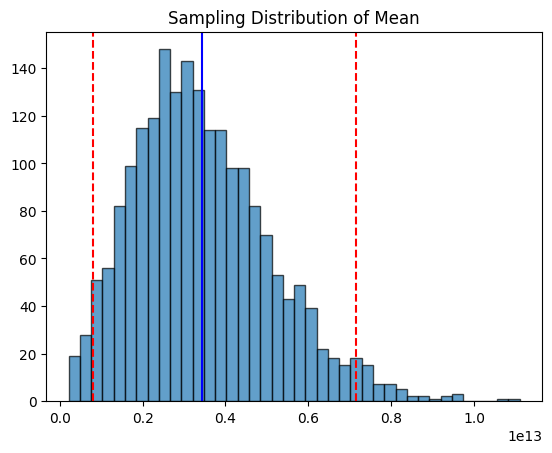

In [ ]:
# sampling distribution
def sampling_distribution(data, n=50, B=1000):
    means = []
    for _ in range(B):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
    return np.array(means)

n_sample = 50
B = 2000
sample_means = sampling_distribution(data.values, n=n_sample, B=B)

# confidence interval 95%
ci_lower = np.percentile(sample_means, 2.5)
ci_upper = np.percentile(sample_means, 97.5)
sample_mean = np.mean(sample_means)

print("Mean sampling distribution :", sample_mean)
print("CI 95% :", (ci_lower, ci_upper))

# visualisasi sampling distribution
plt.hist(sample_means, bins=40, edgecolor='black', alpha=0.7)
plt.axvline(ci_lower, color='red', linestyle='--')
plt.axvline(ci_upper, color='red', linestyle='--')
plt.axvline(sample_mean, color='blue', linestyle='-')
plt.title("Sampling Distribution of Mean")
plt.show()

**Interpretasi:**

Mean dari sampling distribution sebesar **3.43 × 10¹² USD** sangat dekat dengan mean populasi (**3.39 × 10¹² USD**), yang menunjukkan bahwa estimator mean dari sampel bersifat tidak bias dan konsisten dalam mendekati parameter populasi.

Confidence interval 95% berada pada rentang **(7.99 × 10¹¹, 7.15 × 10¹²)**. Interval ini cukup lebar, yang menunjukkan adanya ketidakpastian dalam estimasi mean akibat variabilitas data yang tinggi.

Lebar interval yang besar mencerminkan bahwa meskipun estimasi pusat cukup stabil, tingkat presisi masih rendah karena sebaran data yang sangat besar.


## 3) Analisis

In [ ]:
# a) representasi sampel
sample_check = df.sample(n=200, random_state=1)['Value (USD)']
sample_mean_check = sample_check.mean()
representativeness_gap = abs(sample_mean_check - pop_mean)

# b) standard error
se = np.std(sample_means, ddof=1)

# c) implikasi keputusan (proxy metric: interval width)
ci_width = ci_upper - ci_lower
results = pd.DataFrame({
    "metric": [
        "sample_mean",
        "population_mean",
        "representativeness_gap",
        "standard_error",
        "CI_width_95%"
    ],
    "value": [
        sample_mean_check,
        pop_mean,
        representativeness_gap,
        se,
        ci_width
    ]
})

print(results)

                   metric         value
0             sample_mean  3.212714e+12
1         population_mean  3.391412e+12
2  representativeness_gap  1.786989e+11
3          standard_error  1.652339e+12
4            CI_width_95%  6.351033e+12


**Interpretasi:**

#### a. Representativitas sampel  
Nilai mean sampel sebesar **3.21 × 10¹² USD** dibandingkan mean populasi **3.39 × 10¹² USD** menghasilkan gap sebesar **1.78 × 10¹¹ USD**, yang relatif kecil dibanding skala data, sehingga sampel dapat dianggap cukup merepresentasikan populasi secara agregat.

#### b. Ketidakpastian estimasi
Standard error sebesar **1.65 × 10¹² USD** menunjukkan tingkat fluktuasi yang tinggi antar sampel. Ini berarti estimasi mean memiliki ketidakpastian yang cukup besar akibat variasi data yang ekstrem.

#### c. Implikasi pengambilan keputusan
CI width sebesar **6.35 × 10¹² USD** menunjukkan rentang ketidakpastian yang luas sehingga keputusan berbasis rata-rata harus dilakukan dengan hati-hati. Dalam konteks ekonomi global, hal ini menyiratkan bahwa kebijakan atau analisis tidak boleh hanya bergantung pada single-point estimate, tetapi harus mempertimbangkan rentang ketidakpastian yang besar.

# **Latihan**

## Latihan 1 — Sampling Methods

Sebuah universitas memiliki 5 fakultas dengan jumlah mahasiswa berbeda. Peneliti ingin mengestimasi rata-rata pengeluaran bulanan mahasiswa.

1. Metode sampling apa yang paling sesuai?
2. Mengapa simple random sampling mungkin kurang ideal jika ukuran fakultas sangat berbeda?
3. Bagaimana cara membuat sampling proporsional berdasarkan fakultas?

In [ ]:
np.random.seed(42)
# simulasi 5 fakultas
fakultas = {
    "A": np.random.normal(2.5, 0.5, 500),
    "B": np.random.normal(3.0, 0.7, 200),
    "C": np.random.normal(1.8, 0.4, 800),
    "D": np.random.normal(2.2, 0.6, 300),
    "E": np.random.normal(3.5, 0.8, 100)
}
population = np.concatenate(list(fakultas.values()))

# stratified sampling proporsional
def stratified_sampling(data_dict, n_total=300):
    sample = []
    total = sum(len(v) for v in data_dict.values())

    for k, v in data_dict.items():
        n_k = int(len(v) / total * n_total)
        sample.append(np.random.choice(v, n_k, replace=False))
    return np.concatenate(sample)

strat_sample = stratified_sampling(fakultas, 300)

**Interpretasi:**

- Peneliti ingin mengestimasi rata-rata pengeluaran mahasiswa dengan kondisi populasi terbagi menjadi 5 fakultas dengan ukuran berbeda.
Metode yang paling sesuai adalah **stratified sampling proporsional** karena setiap fakultas memiliki ukuran dan karakteristik yang berbeda sehingga setiap strata harus terwakili sesuai proporsinya.

- Simple random sampling kurang ideal karena berisiko tidak mewakili fakultas kecil atau besar secara seimbang sehingga estimasi rata-rata bisa bias terhadap fakultas tertentu.

- Sampling proporsional dilakukan dengan membagi jumlah sampel berdasarkan proporsi ukuran tiap fakultas terhadap total populasi. Tujuannya agar distribusi sampel mencerminkan struktur populasi asli.


## Latihan 2 — Sampling Distribution

Buat populasi sintetis berukuran 50.000 dari distribusi gamma dengan parameter bebas.

1. Visualisasikan distribusi populasinya.
2. Ambil 3000 sampel berukuran 10, lalu simpan mean setiap sampel.
3. Ulangi untuk ukuran sampel 50 dan 200.
4. Bandingkan bentuk sampling distribution.

sd_10:  [5.57744104 4.90510189 3.39334713 ... 2.43296229 4.1237689  4.76522679]
sd_50:  [3.90777647 4.44234371 3.90701581 ... 3.92870261 3.91309837 3.39850434]
sd_200:  [3.82851149 3.95866328 4.05730459 ... 4.28976815 3.81046967 3.90715711]


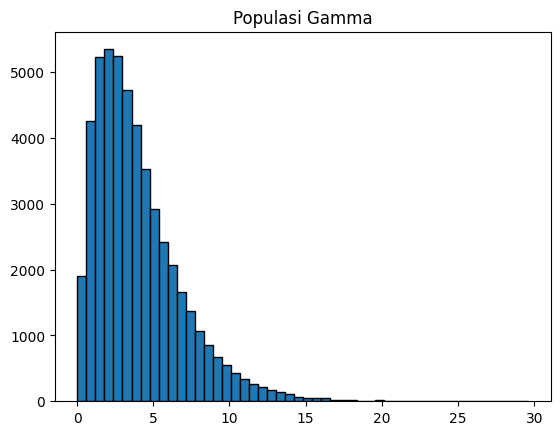

In [ ]:
# populasi gamma
pop_gamma = np.random.gamma(shape=2, scale=2, size=50000)

def sampling_dist(data, n, B=3000):
    means = []
    for _ in range(B):
        samp = np.random.choice(data, n, replace=False)
        means.append(np.mean(samp))
    return np.array(means)

sd_10 = sampling_dist(pop_gamma, 10)
sd_50 = sampling_dist(pop_gamma, 50)
sd_200 = sampling_dist(pop_gamma, 200)
print('sd_10: ', sd_10)
print('sd_50: ', sd_50)
print('sd_200: ', sd_200)

plt.hist(pop_gamma, bins=50, edgecolor='black')
plt.title("Populasi Gamma")
plt.show()

**Interpretasi:**

- Hasil visualisasi populasi gamma menunjukkan grafik cenderung miring ke kanan. Artinya, sebagian besar nilai berada pada rentang kecil, tetapi terdapat beberapa nilai besar yang membentuk ekor panjang di sisi kanan.

- Ketika dilakukan pengambilan sampel berulang (B = 3000), distribusi rata-rata sampel akan lebih stabil dan mulai mendekati bentuk normal (sesuai Central Limit Theorem), meskipun distribusi asalnya tidak simetris.

- Untuk n kecil (misalnya 10), variasi antar mean masih besar. Ketika n meningkat (50 dan 200), distribusi semakin sempit dan lebih terpusat yang menunjukkan bahwa rata-rata sampel menjadi lebih stabil dan konsisten.


## Latihan 3 — Standard Error

Gunakan populasi dari Latihan 2.

1. Hitung standard error teoritis untuk n = 10, 50, dan 200.
2. Hitung standard error empiris dari simulasi.
3. Bandingkan keduanya.
4. Jelaskan hasilnya.

In [ ]:
def se_empirical(sample_means):
    return np.std(sample_means, ddof=1)
def se_theoretical(pop_var, n):
    return np.sqrt(pop_var / n)

pop_var = np.var(pop_gamma, ddof=1)

se10_emp = se_empirical(sd_10)
se50_emp = se_empirical(sd_50)
se200_emp = se_empirical(sd_200)

se10_theo = se_theoretical(pop_var, 10)
se50_theo = se_theoretical(pop_var, 50)
se200_theo = se_theoretical(pop_var, 200)

print('se10_emp: ', se10_emp)
print('se50_emp: ', se50_emp)
print('se200_emp: ', se200_emp)
print('se10_theo: ', se10_theo)
print('se50_theo: ', se50_theo)
print('se200_theo: ', se200_theo)

se10_emp:  0.9060793341380075
se50_emp:  0.4025642101098899
se200_emp:  0.20164925519728338
se10_theo:  0.8962355161716673
se50_theo:  0.400808707601892
se200_theo:  0.200404353800946


**Interpretasi:**

Hasil menunjukkan bahwa standard error empiris dan teoritis sangat konsisten:

- n = 10 → SE emp 0.906 vs teoritis 0.896  
- n = 50 → SE emp 0.402 vs teoritis 0.401  
- n = 200 → SE emp 0.202 vs teoritis 0.200  

Kedua nilai hampir identik, menunjukkan bahwa rumus teoritis **SE = σ/√n** sangat akurat dalam memprediksi variasi sampling mean. Terlihat juga bahwa semakin besar ukuran sampel, standard error semakin kecil.


## Latihan 4 — Confidence Interval Mean

Ambil satu sampel berukuran 40 dari populasi gamma pada Latihan 2.

1. Hitung mean sampel.
2. Bangun CI 90%, 95%, dan 99%.
3. Bandingkan lebar interval.
4. Jelaskan hubungan confidence level dan margin of error.

In [ ]:
sample_ci = np.random.choice(pop_gamma, 40, replace=False)
def ci_mean(sample, conf):
    n = len(sample)
    mean = np.mean(sample)
    s = np.std(sample, ddof=1)
    t = stats.t.ppf(1 - (1-conf)/2, df=n-1)
    me = t * s / np.sqrt(n)
    return mean, (mean-me, mean+me)

ci90 = ci_mean(sample_ci, 0.90)
ci95 = ci_mean(sample_ci, 0.95)
ci99 = ci_mean(sample_ci, 0.99)
print('CI 90%: ', ci90)
print('CI 95%: ', ci95)
print('CI 99%: ', ci99)

CI 90%:  (np.float64(4.242323736614193), (np.float64(3.3362807707568436), np.float64(5.148366702471542)))
CI 95%:  (np.float64(4.242323736614193), (np.float64(3.1546200506926323), np.float64(5.330027422535753)))
CI 99%:  (np.float64(4.242323736614193), (np.float64(2.7861412216829446), np.float64(5.6985062515454405)))


**Interpretasi:**

Confidence interval menunjukkan rentang estimasi mean populasi berdasarkan satu sampel.

- CI 90%: (3.34, 5.15)  
- CI 95%: (3.15, 5.33)  
- CI 99%: (2.79, 5.70)  

Terlihat bahwa semakin tinggi tingkat kepercayaan, semakin lebar intervalnya. Hal ini terjadi karena kita membutuhkan rentang yang lebih besar untuk memastikan parameter populasi lebih mungkin tercakup. Margin of error meningkat seiring kenaikan confidence level, yang menunjukkan trade-off antara **presisi (sempitnya interval)** dan **keyakinan (probabilitas mencakup parameter)**.


## Latihan 5 — Confidence Interval Proporsi

Dalam survei 800 responden, 536 menyatakan puas terhadap layanan digital.

1. Hitung proporsi sampel.
2. Bangun confidence interval 95%.
3. Interpretasikan hasilnya.
4. Apa yang terjadi jika ukuran sampel hanya 80 dengan proporsi yang sama?

In [ ]:
x = 536
n = 800
p_hat = x/n

z = stats.norm.ppf(0.975)
se = np.sqrt(p_hat*(1-p_hat)/n)
ci_prop_95 = (p_hat - z*se, p_hat + z*se)

# small sample comparison
x2 = int(p_hat * 80)
n2 = 80
p_hat2 = x2/n2
se2 = np.sqrt(p_hat2*(1-p_hat2)/n2)
ci_prop_small = (p_hat2 - z*se2, p_hat2 + z*se2)
print('CI 95%: ', ci_prop_95)
print('CI small sample: ', ci_prop_small)

CI 95%:  (np.float64(0.6374165198057461), np.float64(0.702583480194254))
CI small sample:  (np.float64(0.5588825435080087), np.float64(0.7661174564919913))


**Interpretasi:**

Untuk sampel besar (n = 800), proporsi kepuasan sebesar sekitar 0.67 dengan CI 95% (0.637, 0.703)
Interval ini cukup sempit yang menunjukkan estimasi proporsi relatif stabil dan memiliki ketidakpastian rendah.

Namun, ketika ukuran sampel kecil (n = 80), interval menjadi (0.559, 0.766).
Interval ini terlihat jauh lebih lebar yang menunjukkan ketidakpastian meningkat signifikan karena informasi yang tersedia lebih sedikit.


## Latihan 6 — Bootstrap

Gunakan data return harian sintetis pada Bagian J.

1. Ambil sampel 60 return.
2. Bangun bootstrap CI 95% untuk mean.
3. Bangun bootstrap CI 95% untuk median.
4. Bandingkan hasilnya dan jelaskan mana yang lebih robust.

In [ ]:
returns = np.random.normal(0.001, 0.02, 2000)
sample_ret = np.random.choice(returns, 60, replace=False)

def bootstrap(sample, B=5000, stat=np.mean):
    out = []
    n = len(sample)
    for _ in range(B):
        res = np.random.choice(sample, n, replace=True)
        out.append(stat(res))
    return np.array(out)

boot_mean = bootstrap(sample_ret, stat=np.mean)
boot_median = bootstrap(sample_ret, stat=np.median)
ci_boot_mean = np.percentile(boot_mean, [2.5, 97.5])
ci_boot_median = np.percentile(boot_median, [2.5, 97.5])

print('CI mean: ', ci_boot_mean)
print('CI median: ', ci_boot_median)

CI mean:  [-0.00898979  0.0006784 ]
CI median:  [-0.01206599  0.00520645]


**Interpretasi:**

Bootstrap distribution untuk mean menghasilkan CI sebesar (-0.0089, 0.0006). Sementara itu, median menghasilkan CI sebesar (-0.0120, 0.0052)

CI median sedikit lebih lebar dibanding mean, menunjukkan bahwa median lebih robust tetapi memiliki variasi bootstrap yang sedikit lebih besar pada sampel ini.

Bootstrap tidak bergantung pada asumsi distribusi normal sehingga lebih fleksibel untuk data return yang sering tidak simetris. Perbedaan hasil ini menunjukkan bahwa median lebih stabil terhadap outlier, sedangkan mean lebih sensitif terhadap perubahan nilai ekstrem.